In [32]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
import os 
main_dir = "/Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset"
os.chdir(main_dir)

In [34]:
from keras.models import load_model

model = load_model('my_model33.keras')

In [35]:
from keras.preprocessing import image
from PIL import Image

In [52]:
IMAGE_HEIGHT = 30
IMAGE_WIDTH = 30
image_path = r"C:\Users\Aarya-2\Documents\ADOG\Projects-PESU\Project-Traffic_Signals\dataset\Train\5\00005_00008_00023.png"
img = Image.open(image_path)
img = img.convert("RGB")
img = img.resize((IMAGE_WIDTH,IMAGE_HEIGHT))

img_array = image.img_to_array(img)
img_array/=255.0
img_array = np.expand_dims(img_array,axis=0)
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [53]:
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons'  }

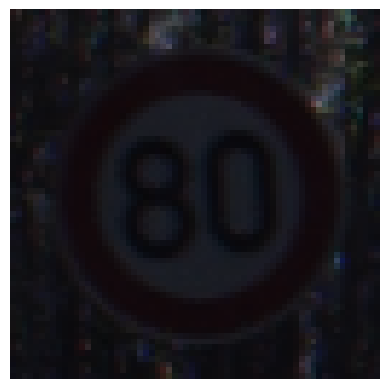

In [54]:
img = image.load_img(image_path)

plt.imshow(img)

plt.axis('off')

plt.show()

In [55]:
print('Prdicted class ' , predicted_class[0])

print('predicted class name :' , classes[predicted_class[0]])

Prdicted class  5
predicted class name : Speed limit (80km/h)


In [56]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd 
from PIL import Image

In [57]:
main_dir = "/Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset"
IMAGE_HEIGHT = 30
IMAGE_WIDTH = 30
batch_size = 500

test_csv = pd.read_csv(main_dir + '/Test.csv')
labels = test_csv['ClassId'].values # contains the true labels of these images  
imgs = test_csv['Path'].values # contains the file path to the images in the test file 

In [58]:
preds = [] # to store the models predictrions 

In [27]:
import cv2
for i in range(0,len(imgs),batch_size): # iterate through 0 to to the last of all the image file paths in test csv , we loop it as per memeoy
    # in the compuert available to controld this memory we use batch_Size 
    b_images = imgs[i:i + batch_size] # slicing the images from i to the i + batch size and take only thoase images for looping 
    b_data = [] # we store the details of the image batch wise in this list 

    for img in b_images:
        image = cv2.imread(main_dir + '/' + img)
        if image is not None:
            image_fromarray = Image.fromarray(image,'RGB')
            resize_image = image_fromarray.resize((IMAGE_HEIGHT,IMAGE_WIDTH))
            b_data.append(np.array(resize_image,dtype = np.float32 )/255.0)
        # we iterste through the images batch wise and convert the image to PIL form if there is an image we convert it from BGR format to the 
        # RGB format and then resize based on our needs and convert them to float ( due to memory issues float64 cdnt be used ) and cobvert  them 
        # to a numpy array by dividing with 255 to get the exact value as 0 - black and 255 - white 
    
    if b_data: # checks of b_data has any images in it 
        batch_array = np.array(b_data) # convert the dta to an numpy array 
        print("Batch data shape:",batch_array.shape)
        preds_batch = model.predict(batch_array) # we predict based on the current batch 
        preds.append(preds_batch) # we collect the predictions of all the batches in predictions 

preds = np.vstack(preds) # vstqack stacks the predictions row wise of all the of all the batch wise array predictions in pres_batch
pred_classes = np.argmax(preds,axis = 1) # This line identifies the predicted class for each

Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Batch data shape: (500, 30, 30, 3)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Batch data shape: (500, 3

In [28]:
print('Testing accuracy ' , accuracy_score(labels,pred_classes) * 100)
# here labels is the true class labels and pred_classes is the prediction by the CNN model 

Testing accuracy  98.74901029295329


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


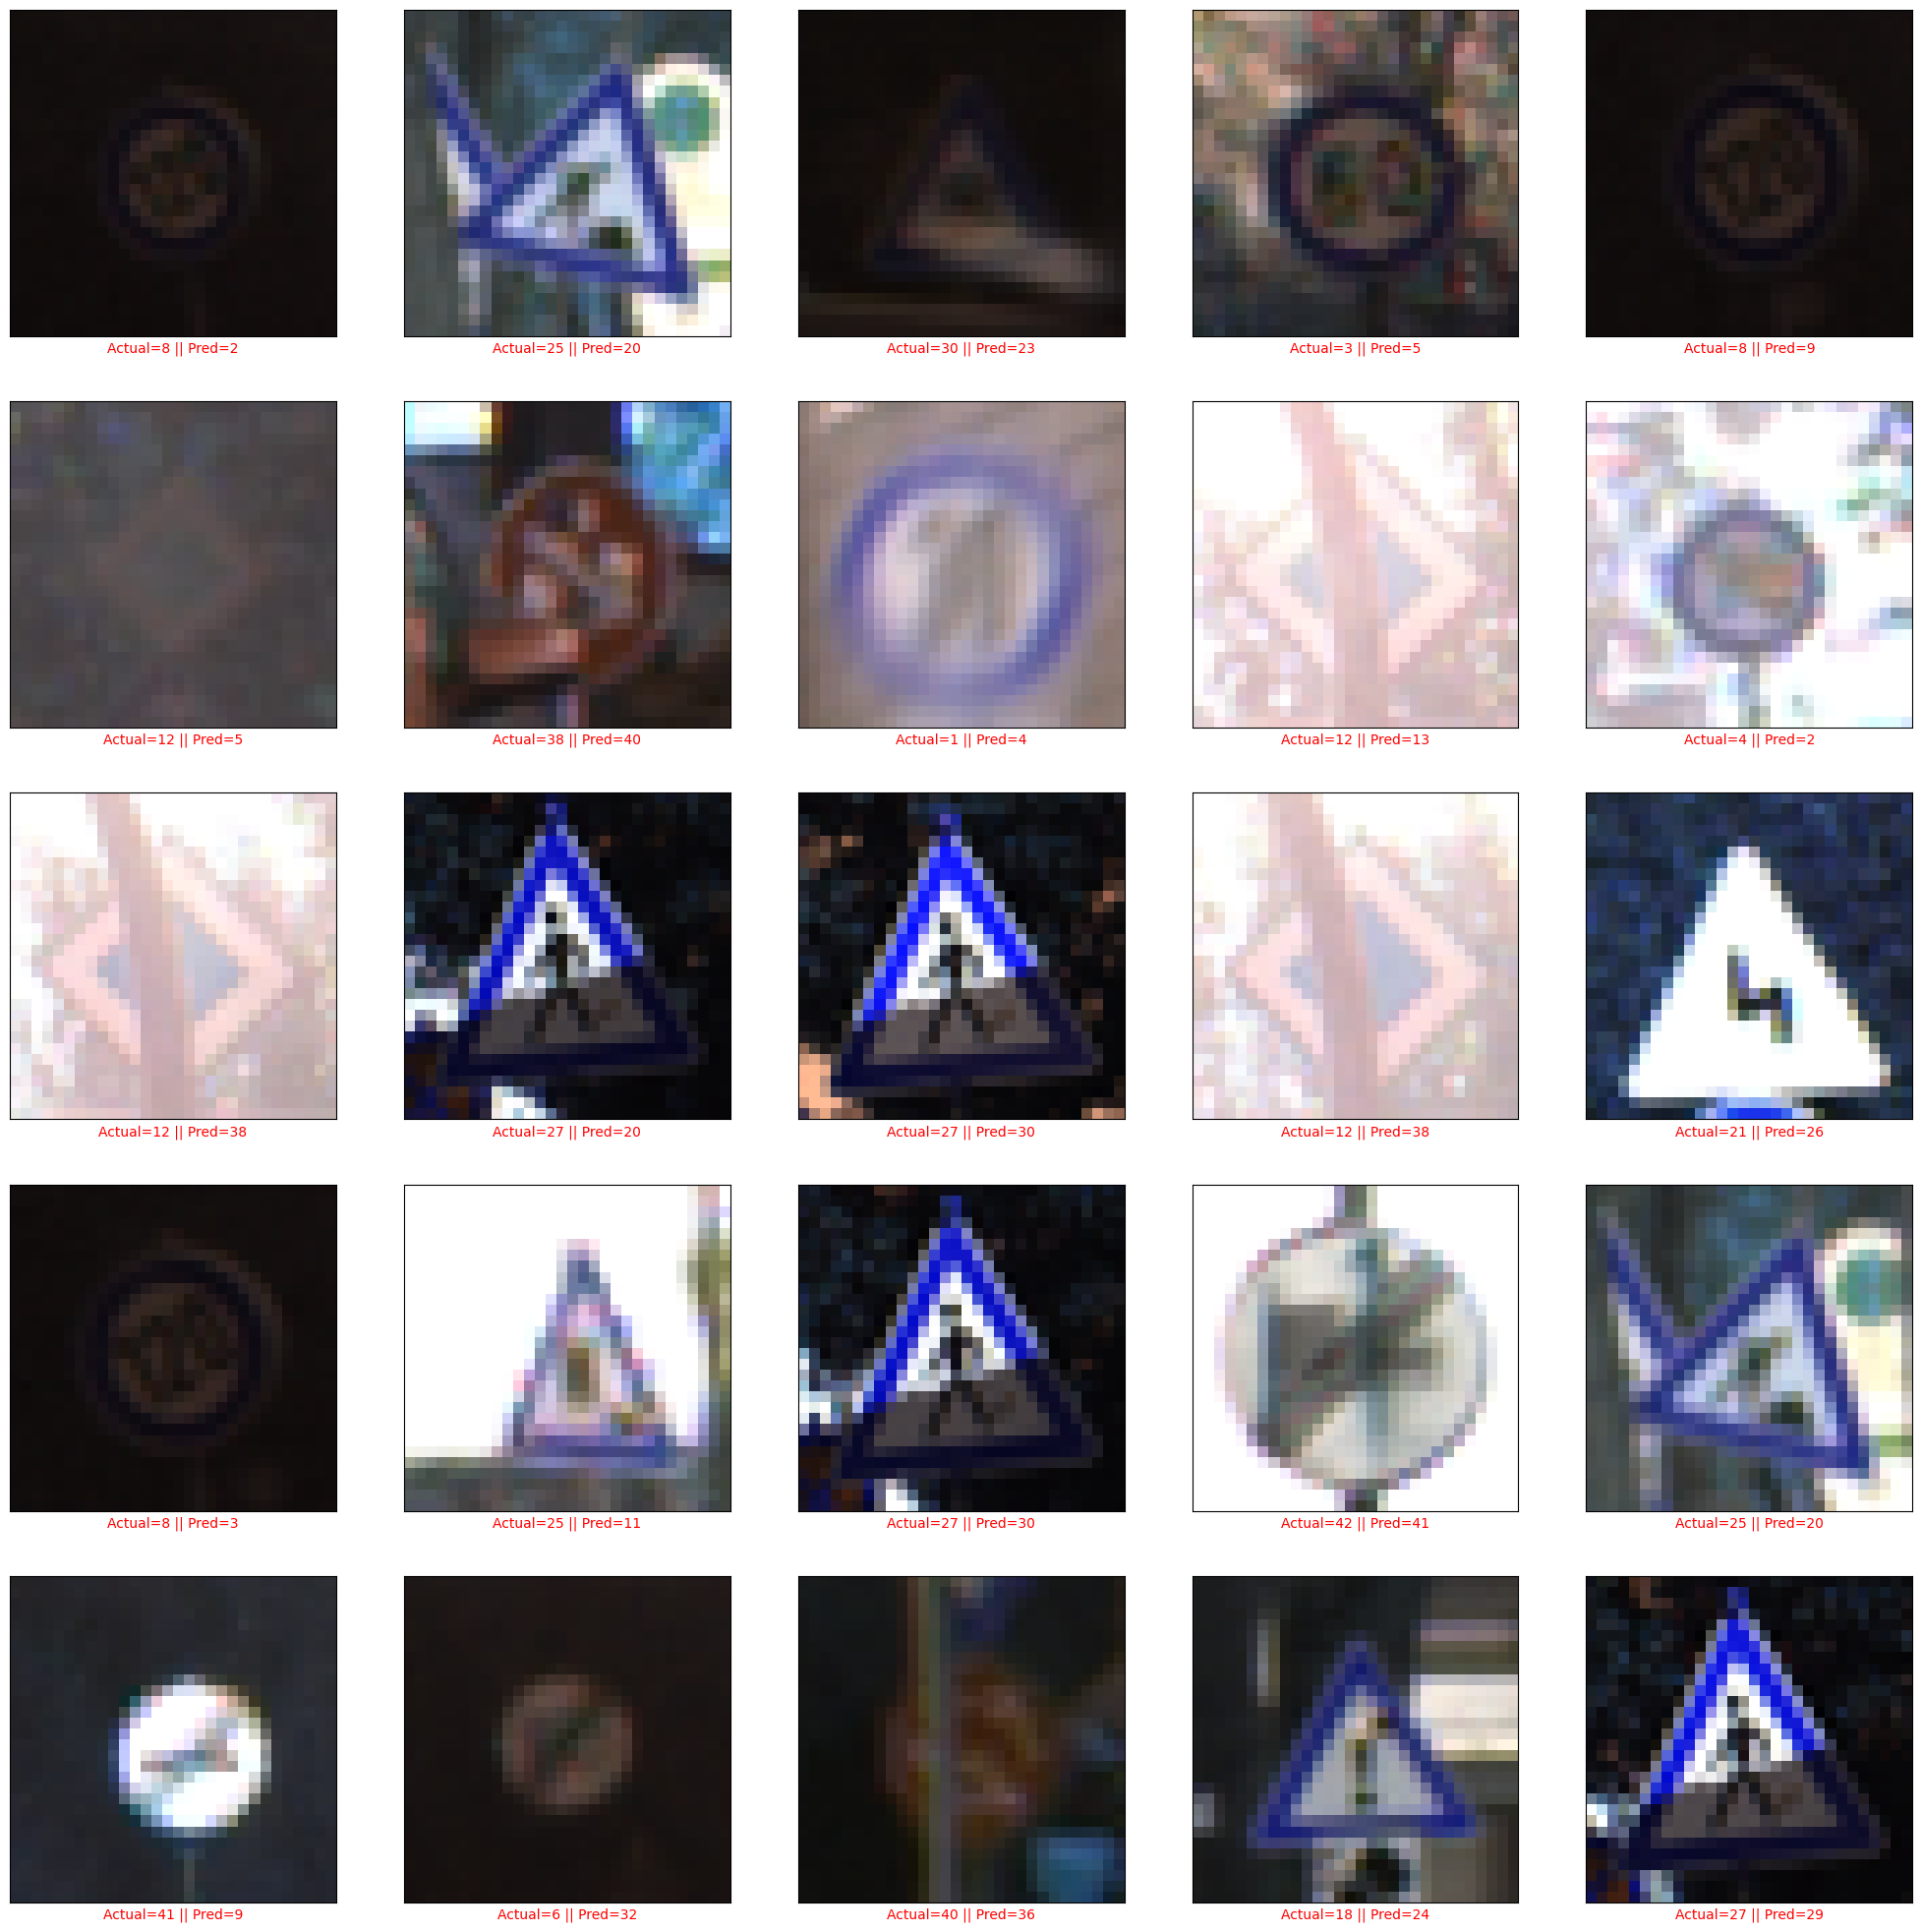


Misclassified Images and their locations:
Image Path: /Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset\Test/00039.png | Actual: 8 | Predicted: 2
Image Path: /Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset\Test/00078.png | Actual: 25 | Predicted: 20
Image Path: /Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset\Test/00114.png | Actual: 30 | Predicted: 23
Image Path: /Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset\Test/00176.png | Actual: 3 | Predicted: 5
Image Path: /Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset\Test/00247.png | Actual: 8 | Predicted: 9
Image Path: /Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset\Test/00265.png | Actual: 12 | Predicted: 5
Image Path: /Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset\Test/00309.png | Actual: 38 | Predicted: 40
Image Path: /Users/Aarya-2/Documents/ADO

In [29]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model
import pandas as pd



# Directory and settings
main_dir = "/Users/Aarya-2/Documents/ADOG/Projects-PESU/Project-Traffic_Signals/dataset"
IMAGE_HEIGHT = 30
IMAGE_WIDTH = 30
batch_size = 500

# Read the test CSV
test_csv = pd.read_csv(main_dir + '/Test.csv')
labels = test_csv['ClassId'].values  # true labels
imgs = test_csv['Path'].values  # image file paths

# Initialize lists for storing failed predictions and image paths
failed_images = []  
failed_labels = [] 
failed_predictions = []  
failed_image_paths = []

# List to store all images
all_images = []

# Initialize predictions list
predictions = []

# Loop through images in batches for prediction
for i in range(0, len(imgs), batch_size):
    batch_imgs = imgs[i:i + batch_size]
    batch_data = []
    batch_image_paths = []  # List to store the image paths for this batch

    for img in batch_imgs:
        image_path = os.path.join(main_dir, img)  # Get full path to image
        image = cv2.imread(image_path)
        if image is not None:
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMAGE_HEIGHT, IMAGE_WIDTH))
            batch_data.append(np.array(resize_image, dtype=np.float32) / 255.0)
            batch_image_paths.append(image_path)  # Store the path for this image
        else:
            print(f"Failed to load image: {image_path}")

    # If batch_data is not empty, make predictions
    if batch_data: 
        batch_array = np.array(batch_data)
        predictions_batch = model.predict(batch_array)  # Get predictions for this batch
        predictions.append(predictions_batch)  # Store predictions for this batch
        all_images.extend(batch_data)  # Store all images (for failed cases later)

        # Step 6: Evaluate accuracy and identify misclassifications
        pred_classes_batch = np.argmax(predictions_batch, axis=1)  # Get predicted class for each image in the batch
        for j in range(len(pred_classes_batch)):
            if pred_classes_batch[j] != labels[i + j]:  # Misclassification
                failed_images.append(batch_data[j])  # Store the failed image
                failed_labels.append(labels[i + j])  # Store the true label
                failed_predictions.append(pred_classes_batch[j])  # Store predicted label
                failed_image_paths.append(batch_image_paths[j])  # Store the image path

# Combine all predictions
if predictions:  # Check if any predictions were made
    predictions = np.vstack(predictions)  # Stack all batch predictions vertically
    pred_classes = np.argmax(predictions, axis=1)  # Get predicted class for each image

    # Evaluate accuracy
    print('Test Data accuracy: ', accuracy_score(labels, pred_classes) * 100)
    
    # Show misclassified images
    if failed_images:
        plt.figure(figsize=(25, 25))
        num_failed_images_to_display = min(25, len(failed_images))
        for i in range(num_failed_images_to_display):
            plt.subplot(5, 5, i + 1)
            plt.grid(False)
            plt.xticks([])
            plt.yticks([])
            prediction = failed_predictions[i]
            actual = failed_labels[i]
            col = 'r'  # Red color for failure
            plt.xlabel(f'Actual={actual} || Pred={prediction}', color=col)
            plt.imshow(failed_images[i])
        plt.show()

        # Print misclassified image paths and predictions
        print("\nMisclassified Images and their locations:")
        for path, true_label, pred_label in zip(failed_image_paths, failed_labels, failed_predictions):
            print(f"Image Path: {path} | Actual: {true_label} | Predicted: {pred_label}")
    else:
        print("All images were correctly classified!")
else:
    print("No predictions were made.")



In [30]:
len(failed_image_paths)

158